<a href="https://colab.research.google.com/github/CoF-Stats/CoFAI-d2l-reading-group-2026/blob/main/notebooks/week05_MLPs_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 05: July 29

## Finishing section 4.7 (distribution shift)

### Questions

- Does anyone recognize what the weights, $\beta_i,\ i=1,2,...,n$ are from the covariate shift correction algorithm?

- I didn't understand the explanation of the *Bandits* problem, or why it is called that.

## Sections 5.1 and 5.2 (MLPs)

### Questions

- What exactly is a *perceptron*? How do we define it? Is it the same as any neural network? Only fully connected networks?



# Exercises

## 4.7.7.2

> Implement a covariate shift detector. Hint: build a classifier.

---

#### Dusty's attempt

In [22]:
!pip install d2l --no-deps

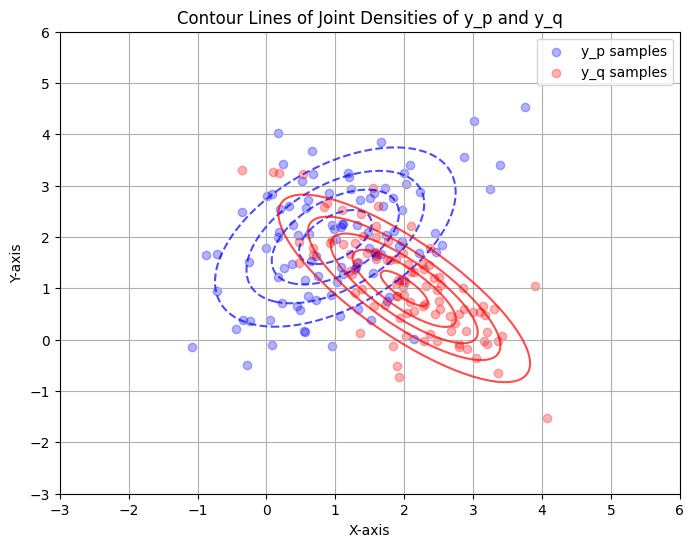

In [23]:
import numpy as np
from d2l import torch as d2l
from numpy import random as r
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# set covariance matrix and means
mu_p = np.array([1, 2])
mu_q = (2, 1)

Sigma_p = np.matrix(data=[[1, 0.5], [0.5, 1]])
Sigma_q = np.matrix(data = [[1, -0.8], [-0.8, 1]])

# first generate some standard normal random variates
y_p = r.multivariate_normal(mu_p, Sigma_p, 100)
y_q = r.multivariate_normal(mu_q, Sigma_q, 100)

# plot y_p and y_q

# Create a grid for contour plots
x = np.linspace(-3, 6, 200)
y = np.linspace(-3, 6, 200)
X, Y = np.meshgrid(x, y)

# Calculate the PDF for each distribution
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

rv_p = multivariate_normal(mu_p, Sigma_p)
rv_q = multivariate_normal(mu_q, Sigma_q)

Z_p = rv_p.pdf(pos)
Z_q = rv_q.pdf(pos)

# Plot the contours
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z_p, colors='blue', alpha=0.7, linestyles='dashed', levels=5)
plt.contour(X, Y, Z_q, colors='red', alpha=0.7, linestyles='solid', levels=5)
plt.scatter(y_p[:, 0], y_p[:, 1], color='blue', alpha=0.3, label='y_p samples')
plt.scatter(y_q[:, 0], y_q[:, 1], color='red', alpha=0.3, label='y_q samples')

plt.title('Contour Lines of Joint Densities of y_p and y_q')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()